# A/B-тестирование

 Цели исследования - провести оценку результатов A/B-теста,  то есть оценить корректность проведения теста и проанализировать результаты теста.<br>
 В исследовании используется датасет с действиями пользователей, техническое задание и несколько вспомогательных датасетов. 

1. [Получение данных](#loading)
2. [Предобработка данных](#preprocessing)
 * [Преобразование типов данных](#type)
 * [Обработка пропусков и дубликатов](#duplicated)
3. [Оценка корректности проведения теста](#correct_test)
 * [Соответствие данных требованиям технического задания](#correct_data)
 * [Проверка времени проведения теста](#correct_time)
 * [Проверка аудитории теста](#correct_auditorium)
4. [Исследовательский анализ данных](#analysis)
 * [Распределение событий на пользователя в выборках](#event_user)
 * [Распределение событий в выборках по дням](#event_day)
 * [Конверсия в выборках на разных этапах](#conversion)
5. [Оценка результатов A/B-тестирования](#AB_test)
6. [Общий вывод](#conclusion)

## Получение данных <a id="loading"></a>

In [1]:
import pandas as pd
from scipy import stats as st
import math as mth
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
ab_events = pd.read_csv('datasets/final_ab_events.csv')
marketing_events = pd.read_csv('datasets/ab_project_marketing_events.csv')
new_users = pd.read_csv('datasets/final_ab_new_users.csv')
ab_participants = pd.read_csv('datasets/final_ab_participants.csv')

In [3]:
for dataset in [ab_events, marketing_events, new_users, ab_participants]:
    dataset.info()
    display(dataset.head())
    print('*'*50)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440317 entries, 0 to 440316
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     440317 non-null  object 
 1   event_dt    440317 non-null  object 
 2   event_name  440317 non-null  object 
 3   details     62740 non-null   float64
dtypes: float64(1), object(3)
memory usage: 13.4+ MB


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


**************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


**************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61733 entries, 0 to 61732
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     61733 non-null  object
 1   first_date  61733 non-null  object
 2   region      61733 non-null  object
 3   device      61733 non-null  object
dtypes: object(4)
memory usage: 1.9+ MB


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


**************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18268 entries, 0 to 18267
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  18268 non-null  object
 1   group    18268 non-null  object
 2   ab_test  18268 non-null  object
dtypes: object(3)
memory usage: 428.3+ KB


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,482F14783456D21B,B,recommender_system_test


**************************************************


Даты по всех датасетах, где они есть, указаны в неправильном формате. Необходимо заменить формат дат на datetime.

## Предобработка данных <a id="preprocessing"></a>

### Преобразование типов данных <a id="type"></a>

In [4]:
# преобразование формата данных
ab_events['event_dt'] = pd.to_datetime(ab_events['event_dt'], format='%Y-%m-%d %H:%M:%S')
marketing_events['start_dt'] = pd.to_datetime(marketing_events['start_dt'], format='%Y-%m-%d')
marketing_events['finish_dt'] = pd.to_datetime(marketing_events['finish_dt'], format='%Y-%m-%d')
new_users['first_date'] = pd.to_datetime(new_users['first_date'], format='%Y-%m-%d')

#проверка формата данных
for column in [ab_events['event_dt'], marketing_events['start_dt'], marketing_events['finish_dt'], new_users['first_date']]:
    print(column.dtypes)

datetime64[ns]
datetime64[ns]
datetime64[ns]
datetime64[ns]


Формат столбцов с датами заменен на datetime.

### Обработка пропусков и дубликатов <a id="duplicated"></a>

In [5]:
#проверка наличия дубикатов
print('Проверка на дубликаты')
for dataset in [ab_events, marketing_events, new_users, ab_participants]:
    print(dataset.duplicated().sum())
    
#проверка наличия пропусков
print('Проверка на пропуски')
for dataset in [ab_events, marketing_events, new_users, ab_participants]:
    print(dataset.isnull().sum())
    print('*'*50)
    

Проверка на дубликаты
0
0
0
0
Проверка на пропуски
user_id            0
event_dt           0
event_name         0
details       377577
dtype: int64
**************************************************
name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64
**************************************************
user_id       0
first_date    0
region        0
device        0
dtype: int64
**************************************************
user_id    0
group      0
ab_test    0
dtype: int64
**************************************************


Ни в одном датасете нет дубликатов. Пропуски есть в датасете events в колонке details. По условиям проекта в данной колонке хранятся дополнительные данные, которые могут заполняться не при каждом событии. Следовательно данные пропуски обрабатывать не нужно.

## Оценка корректности проведения теста <a id="correct_test"></a>

### Соответствие данных требованиям технического задания <a id="correct_data"></a>

In [6]:
#объединение датасетов
temp = pd.merge(ab_participants, new_users, left_on='user_id', right_on='user_id', how='left')
ab_test = pd.merge(temp, ab_events, left_on='user_id', right_on='user_id', how='left')

In [7]:
#проверка названия теста
print(f'Проводились тесты: {ab_test.ab_test.unique()}')
#проверка дат проведения второго теста
print(ab_test.query('ab_test == "interface_eu_test"')['event_dt'].min())
print(ab_test.query('ab_test == "interface_eu_test"')['event_dt'].max())
#удаление данных другого теста
ab_test = ab_test.query('ab_test == "recommender_system_test"')

Проводились тесты: ['recommender_system_test' 'interface_eu_test']
2020-12-07 00:02:48
2020-12-30 18:28:55


В датасете есть данные по двум тестам. Даты проведения тестов пересекаются. 
Так как исследование проводится только по тесту recommender_system_test, необходимо удалить данные другого теста из сводного датасета.

In [8]:
#проверка региона новых пользователей и доли этих пользователей 
print('Регионы пользователей', ab_test.query('group == "A"| group == "B"')['region'].unique())
print(
    'Доля пользователей AB-теста среди всех новых пользователей региона EU -',
    round(ab_test.query('region == "EU"')['user_id'].nunique()/
    new_users.query('region == "EU"')['user_id'].nunique(), 2)
)
# удаление пользователей из других регионов
ab_test = ab_test.query('region == "EU"')

Регионы пользователей ['EU' 'N.America' 'CIS' 'APAC']
Доля пользователей AB-теста среди всех новых пользователей региона EU - 0.14


 1. В тест попали не только пользователи EU. Это не соотвествует техническому заданию, поэтому пользователей из других регионов нужно удалить.
 2. В соответствие с технических заданием в тест долно было попасть 15% новых пользователей из региона EU. Фактически 14%.

### Проверка времени проведения теста <a id="correct_time"></a>

In [9]:
#проверка соответствия дат техническому заданию 
print(f'Фактическая дата запуска теста - {ab_test.first_date.min()}')
print(f'Фактическая дата остановки набора новых пользователе - {ab_test.first_date.max()}')
print(f'Минимальная дата действия пользователей - {ab_test.event_dt.min()}')
print(f'Максимальная дата действия пользователей - {ab_test.event_dt.max()}')
print('-'*20)
#проверка все ли пользователи смогли "прожить" 14 дней
life_time = ab_test.groupby('user_id', as_index=False).agg({'first_date':'max',
                                                            'event_dt':'max'})
print('Пользователи со сроком "жизни" меньше 14 дней, но больше 0')
display(life_time.query('(event_dt - first_date).dt.days < 14 & event_dt.notnull()')['event_dt'].count())
print('Пользователи не совершившие ни одного события')
display(life_time.isnull()['event_dt'].sum())

Фактическая дата запуска теста - 2020-12-07 00:00:00
Фактическая дата остановки набора новых пользователе - 2020-12-21 00:00:00
Минимальная дата действия пользователей - 2020-12-07 00:05:57
Максимальная дата действия пользователей - 2020-12-30 12:42:57
--------------------
Пользователи со сроком "жизни" меньше 14 дней, но больше 0


3147

Пользователи не совершившие ни одного события


2870

1. Дата запуска теста соответствует техническому заданию (2020-12-07). 
2. Дата остановки набора новых пользователей соответствует техническому заданию  (2020-12-21). 
3. Период окончания действий новых пользователей не соответствует техническому заданию. По техническому заданию  2021-01-04, фактически последние действия пользователей были записаны 2020-12-30.
<b>
4. В данных есть 2870 пользователей не совершивших ни одного действия, то есть эти пользователи даже незарегистрировались. Удалять данных пользователей нельзя, так как показатель конверсии пользователей на этапе регистрации тоже важен для анализа поведения пользователей.
5. Также в даных есть 3147 пользователей со сроком "жизни" меньше 14 дней, то есть разница между регистрацией и последней активностью пользователя меньше 14 дней. Данных пользователей также нельзя удалять. Так как количество таких пользоваталей существенное и возможно это связано с особенностями использования данного приложения (например, есть активные пользователи и пользователи которые используют приложение 1-2 раза в месяц).
 </b> </div>

In [10]:
#проверка совпадения времени теста с маркетинговыми и другими активностями
date_start_test = pd.Timestamp('2020-12-07')
date_stop_test = pd.Timestamp('2021-01-04')


def check_date(row):
    if row['start_dt'] <= date_stop_test <= row['finish_dt']:
        return True
    elif row['start_dt'] <= date_start_test <= row['finish_dt']:
        return True
    elif date_start_test <= row['start_dt'] <= date_stop_test:
        return True
    else:
        return False
    
marketing_events[marketing_events.apply(lambda x: check_date(x), axis=1)]

,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
10,CIS New Year Gift Lottery,CIS,2020-12-30,2021-01-07


Во время проведения теста проводилось две маркетинговые активности. Одна из данных активностей проводилась в регионе теста - EU.
Также следует отметить, что время проведения теста приходится на предновогодний период. Поведение пользователей в данный период не является обычным. Эти факторы могут существенно повлиять на результаты теста.

### Проверка аудитории теста <a id="correct_auditorium"></a>

In [11]:
#проверка  наличия пользователей, участвующих в двух группах теста одновременно 
test_A = ab_test.query('group == "A"')
test_B = ab_test.query('group == "B"')
users_AB = pd.merge(test_A, test_B, left_on='user_id', right_on='user_id', how='inner')['user_id']
print(f'Количество пользователей попавших в обе группы теста {users_AB.nunique()}')

Количество пользователей попавших в обе группы теста 0


In [12]:
# проверка пересечения аудитории с другими тестами
test_r = ab_participants.query('ab_test == "recommender_system_test"')
test_i = ab_participants.query('ab_test == "interface_eu_test"')
test_ri = pd.merge(test_r, test_i, left_on='user_id', right_on='user_id', how='inner')
print('Количество пользователей попавших в два теста', test_ri['user_id'].nunique())

#удаление пользователей попавших в оба теста 
ab_test = ab_test.query('user_id not in @test_ri.user_id')

Количество пользователей попавших в два теста 1602


Всего 1602 пользователя попали в оба теста. Время проведения тестов пересекается. Данных пользователей необходимо удалить, так как будет невозможно определить что какой именно тест и как именно влияет на поведение этих пользователей. 

In [13]:
#проверка ожидаемого количества участников теста
print('Фактическое количество участников теста', ab_test.query('ab_test == "recommender_system_test"').user_id.nunique())

Фактическое количество участников теста 4749


В соответствие с техническим заданием ожидаемое количество участников теста - 6000. Фактически после удаления всех ошибок из данных осталось 4749 участника, что меньше ожидаемого количества.

Группа А - 2713
Группа В - 2036
0.33


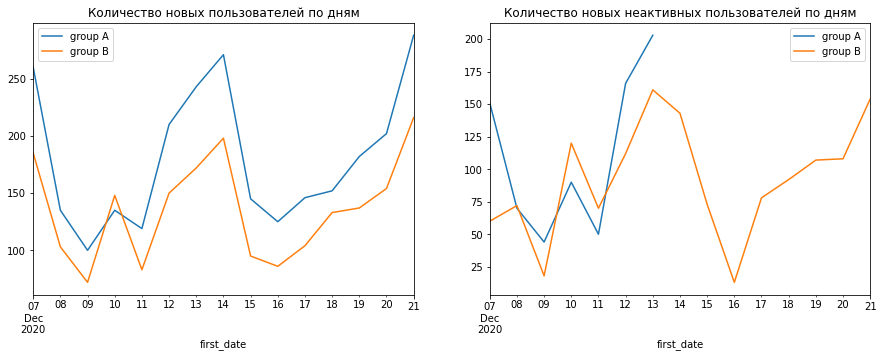

In [14]:
#проверка равномерность распределения по тестовым группам и правильность их формирования
print('Группа А -', ab_test.query('group == "A"').user_id.nunique())
print('Группа В -', ab_test.query('group == "B"').user_id.nunique())
print(round((ab_test.query('group == "A"').user_id.nunique()
       -ab_test.query('group == "B"').user_id.nunique())
      /ab_test.query('group == "B"').user_id.nunique(), 2))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (15, 5))

(
    ab_test.query('group == "A"')
    .groupby('first_date')['user_id']
    .nunique()
    .plot(label='group A', legend=True, ax=ax1))
(
    ab_test.query('group == "B"')
    .groupby('first_date')['user_id']
    .nunique()
    .plot(label='group B', legend=True, ax=ax1, title = 'Количество новых пользователей по дням'))

#динамика набора неактивных пользователей
not_active_users = life_time.query('event_dt.isna()')['user_id']

(
    ab_test.query('group == "A" & user_id in @not_active_users')
    .groupby('first_date')['user_id']
    .nunique()
    .plot(label='group A', legend=True, ax=ax2))
(
    ab_test.query('group == "B" & user_id in @not_active_users')
    .groupby('first_date')['user_id']
    .nunique()
    .plot(label='group B', legend=True, ax=ax2, title='Количество новых неактивных пользователей по дням'))
plt.show()

Группа А больше Группы В на 33%. По дням группы формировались практически идентично. Набор неактивных пользователей не равномерен между группами - в группу А после 13 декабря не поступают неактивные пользователи, а в группу В продолжили поступать. 

## Исследовательский анализ данных <a id="analysis"></a>

### Распределение событий на пользователя в выборках<a id="event_user"></a>

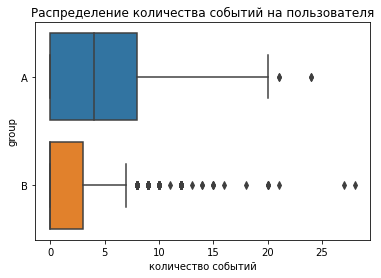

In [15]:
sns.boxplot(data = ab_test.groupby(['group', 'user_id'], as_index=False)['event_name'].count(), 
            x='event_name', 
            y='group')
plt.title('Распределение количества событий на пользователя')
plt.xlabel('количество событий')
plt.show()

Количество событий на пользователя в группах распределено не одинаково. В группе А 50% пользователей совершили от 0 до 8 событий, медианное количество событий - 4. В группе В 50% пользователей совершили от 0 до 3 событий и медианной количество событий - 0. 

### Распределение событий в выборках по дням <a id="event_day"></a>

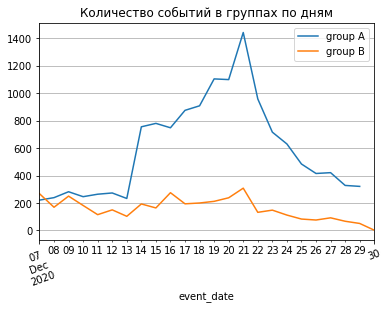

In [16]:
ab_test['event_date'] = pd.to_datetime(ab_test['event_dt'].dt.date)
ab_test.query('group == "A"').groupby('event_date')['event_date'].count().plot(grid=True, label='group A', legend=True)
ab_test.query('group == "B"').groupby('event_date')['event_date'].count().plot(grid=True, label='group B', legend=True)
plt.xticks(rotation=20)
plt.title('Количество событий в группах по дням')
plt.show()

Количество событий в группах по дням также распределно не равномерно. Количество событий в группе А превышает количество событий в группе В. Количество событий в группе А резко выросло после 14 декабря и начало снижаться после 21 декабря.

In [17]:
ab_test

,user_id,group,ab_test,first_date,region,device,event_dt,event_name,details,event_date
0,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:27,purchase,99.99,2020-12-07
1,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-25 00:04:56,purchase,4.99,2020-12-25
2,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:29,product_cart,NaN,2020-12-07
3,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-25 00:04:57,product_cart,NaN,2020-12-25
4,D1ABA3E2887B6A73,A,recommender_system_test,2020-12-07,EU,PC,2020-12-07 14:43:27,product_page,NaN,2020-12-07
...,...,...,...,...,...,...,...,...,...,...
26285,80712ED4EA1B52A5,A,recommender_system_test,2020-12-14,EU,Android,2020-12-15 20:10:06,product_page,NaN,2020-12-15
26286,80712ED4EA1B52A5,A,recommender_system_test,2020-12-14,EU,Android,2020-12-20 20:01:34,product_page,NaN,2020-12-20
26287,80712ED4EA1B52A5,A,recommender_system_test,2020-12-14,EU,Android,2020-12-14 05:48:50,login,NaN,2020-12-14
26288,80712ED4EA1B52A5,A,recommender_system_test,2020-12-14,EU,Android,2020-12-15 20:10:03,login,NaN,2020-12-15


### Конверсия в выборках на разных этапах <a id="conversion"></a>

In [18]:
#кумулятивная конверсия группа А
#количество уникальных пользоваталей по датам и типам событий нарастающим итогом
group_A = ab_test.query('group == "A"').groupby(['event_name', 'event_date'], as_index=False)['user_id'].nunique()
a_test = ab_test.query('group == "A"')
cumulative_group_A = (
    group_A.apply(lambda x: a_test[np.logical_and(a_test['event_name'] == x['event_name'],
                                                  a_test['event_date'] <= x['event_date'])]
                  .agg({'event_date' : 'max', 'group' : 'max', 'event_name' : 'max', 'user_id':'nunique'}), axis=1)
)
cumulative_group_A = pd.pivot_table(cumulative_group_A, 
                                    index=['group','event_date'], 
                                    columns='event_name', 
                                    values='user_id',
                                    aggfunc='max')

cumulative_group_A.reset_index(inplace=True)

#новые пользователи нарастающим итогом
cum_new_user_A = (
    group_A.apply(lambda x: a_test[a_test['first_date'] <= x['event_date']]
                   .agg({'first_date': 'max', 'user_id':'nunique'}), axis=1).drop_duplicates()
)

#добавление новых пользователей в сводную таблицу с событиями
cumulative_group_A = pd.merge(cumulative_group_A, 
                              cum_new_user_A, 
                              left_on='event_date', 
                              right_on='first_date',
                              how = 'outer')


cumulative_group_A.drop('first_date', axis=1, inplace=True)
cumulative_group_A.fillna(cum_new_user_A['user_id'].max(), inplace=True)

cumulative_group_A[['conv_login', 'conv_product_cart', 'conv_product_page', 'conv_purchase']] = (
    cumulative_group_A[['login', 'product_cart', 'product_page', 'purchase']]
          .div(cumulative_group_A['user_id'], axis=0)
)

display(cumulative_group_A.head())

#кумулятивная конверсия группа В
#количество уникальных пользоваталей по датам и типам событий нарастающим итогом
group_B = ab_test.query('group == "B"').groupby(['event_name', 'event_date'], as_index=False)['user_id'].nunique()
b_test = ab_test.query('group == "B"')
cumulative_group_B = (
    group_B.apply(lambda x: b_test[np.logical_and(b_test['event_name'] == x['event_name'],
                                                  b_test['event_date'] <= x['event_date'])]
                  .agg({'event_date' : 'max', 'group' : 'max', 'event_name' : 'max', 'user_id':'nunique'}), axis=1)
)

cumulative_group_B = pd.pivot_table(cumulative_group_B, 
                                    index=['group','event_date'], 
                                    columns='event_name', 
                                    values='user_id',
                                    aggfunc='max')

cumulative_group_B.reset_index(inplace=True)

#новые пользователи нарастающим итогом
cum_new_user_B = (
    group_B.apply(lambda x: b_test[b_test['first_date'] <= x['event_date']]
                   .agg({'first_date': 'max', 'user_id':'nunique'}), axis=1).drop_duplicates()
)

#добавление новых пользователей в сводную таблицу с событиями
cumulative_group_B = pd.merge(cumulative_group_B, 
                              cum_new_user_B, 
                              left_on='event_date', 
                              right_on='first_date',
                              how = 'outer')


cumulative_group_B.drop('first_date', axis=1, inplace=True)
cumulative_group_B['user_id'].fillna(cum_new_user_B['user_id'].max(), inplace=True)
purchase_max = cumulative_group_B['purchase'].max()
cumulative_group_B['purchase'].fillna(purchase_max, inplace=True)

cumulative_group_B[['conv_login', 'conv_product_cart', 'conv_product_page', 'conv_purchase']] = (
    cumulative_group_B[['login', 'product_cart', 'product_page', 'purchase']]
    .div(cumulative_group_B['user_id'], axis=0)
)
display(cumulative_group_B.head())

,group,event_date,login,product_cart,product_page,purchase,user_id,conv_login,conv_product_cart,conv_product_page,conv_purchase
0,A,2020-12-07,103,25,66,27,260.0,0.396154,0.096154,0.253846,0.103846
1,A,2020-12-08,170,45,113,45,395.0,0.430380,0.113924,0.286076,0.113924
2,A,2020-12-09,227,60,147,64,495.0,0.458586,0.121212,0.296970,0.129293
3,A,2020-12-10,273,73,171,79,630.0,0.433333,0.115873,0.271429,0.125397
4,A,2020-12-11,343,95,208,90,749.0,0.457944,0.126836,0.277704,0.120160


,group,event_date,login,product_cart,product_page,purchase,user_id,conv_login,conv_product_cart,conv_product_page,conv_purchase
0,B,2020-12-07,114.0,31.0,76.0,47.0,185.0,0.616216,0.167568,0.410811,0.254054
1,B,2020-12-08,149.0,41.0,89.0,52.0,288.0,0.517361,0.142361,0.309028,0.180556
2,B,2020-12-09,205.0,58.0,123.0,63.0,360.0,0.569444,0.161111,0.341667,0.175000
3,B,2020-12-10,234.0,63.0,134.0,70.0,508.0,0.460630,0.124016,0.263780,0.137795
4,B,2020-12-11,247.0,66.0,140.0,72.0,591.0,0.417936,0.111675,0.236887,0.121827


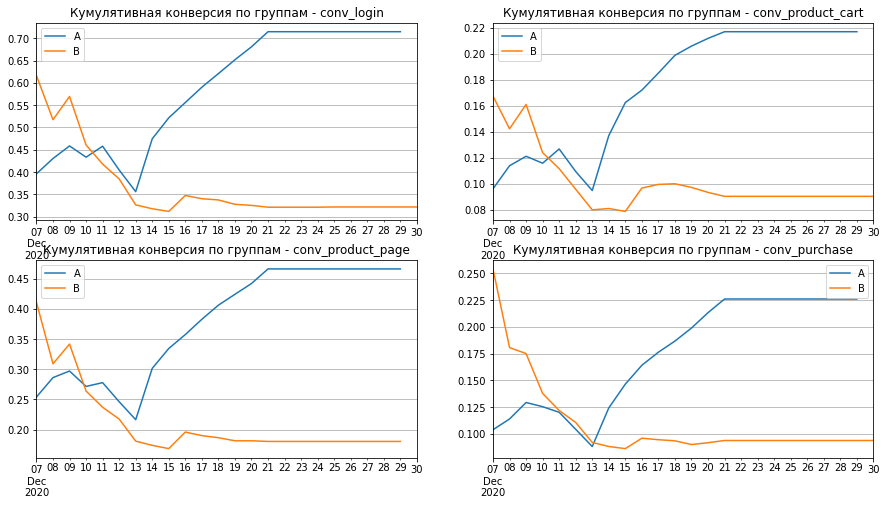

In [19]:
#график кумулятивной конверсии по группам
warnings.filterwarnings("ignore", category=UserWarning)
fig, ax = plt.subplots(2,2, figsize = (15, 8))
for number, column in enumerate(['conv_login', 'conv_product_cart', 'conv_product_page', 'conv_purchase']):
    cumulative_group_A.plot(x='event_date', y=column, label='A', ax=plt.subplot(2, 2, number+1), grid=True)
    cumulative_group_B.plot(x='event_date', y=column, label='B', ax=plt.subplot(2, 2, number+1), grid=True)
    plt.legend()
    plt.title(f'Кумулятивная конверсия по группам - {column}')
    plt.xticks(rotation=0)
    plt.xlabel('')
plt.show()

Конверсия в группе А резко увеличилась 14 декабря по всем метрикам, в группе В подобной тенденции нет. Это явно не типичное поведение пользователей, вероятнее всего это связано с неучтенными внешними факторами. 

Конверсия по всем метикам в контрольной группе больше, чем в тестовой более чем в 2 раза. 

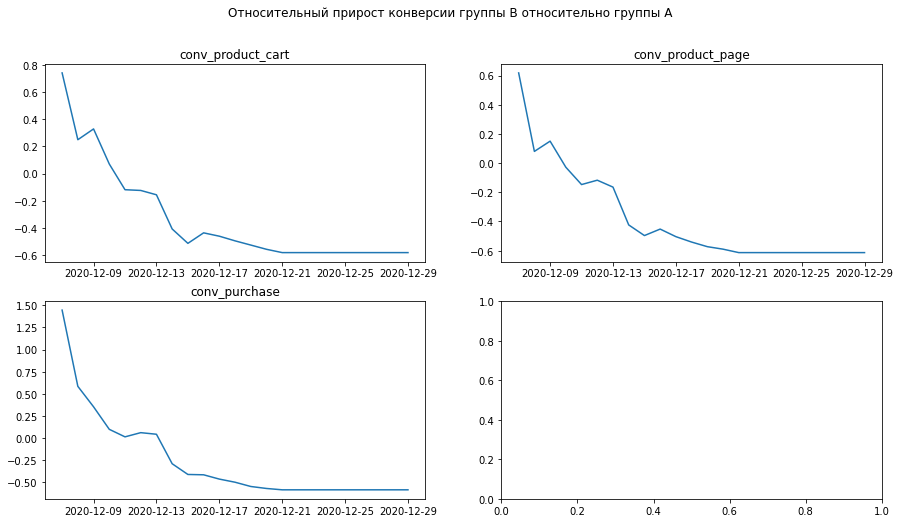

In [20]:
#график относительного изменения кумулятивной конверсии группы B к группе A
fig, ax = plt.subplots(2,2, figsize = (15, 8))
for number, column in enumerate(['conv_login', 'conv_product_cart', 'conv_product_page', 'conv_purchase']):
    plt.plot(cumulative_group_B['event_date'], cumulative_group_B[column]/cumulative_group_A[column]-1)
    plt.title(column)
    plt.xticks(rotation=0)
    plt.subplot(2,2,number+1)
    plt.xlabel('')
plt.suptitle('Относительный прирост конверсии группы B относительно группы A')
plt.show()

Соотношение относительно прироста конверсии в группах отрицательное, они снижается на протяжении всего теста. Вероятнее всего это связано с тем, что группы были сформированы не корректно. И на поведение пользователей влияет дополнительный неучтенный фактор.  

## Оценка результатов A/B-тестирования <a id="AB_test"></a>

Нулевая гипотеза: различий в конверсиях нет

Альтернативная гипотеза:  улучшение каждой конверсии не менее, чем на 10%:
- конверсии в просмотр карточек товаров — событие `product_page`,
- просмотры корзины — `product_cart`,
- покупки — `purchase`.

Таким образом, необходимо проверить три гипотезы. 

In [21]:
alpha = 0.05/3 #добавлена поправка Бонферрнони для множественного сравнения

for column in ['product_cart', 'product_page', 'purchase']: 
    p1 = cumulative_group_A[column].max()/cumulative_group_A['user_id'].max()
    p2 = cumulative_group_B[column].max()/cumulative_group_B['user_id'].max()
    p_combined = ((cumulative_group_A[column].max() + cumulative_group_B[column].max()) / 
                  (cumulative_group_A['user_id'].max() + cumulative_group_B['user_id'].max()))
    
    difference = p1 - p2
    
    z_value = (
        difference / mth.sqrt(p_combined * (1-p_combined) * 
                              (1/cumulative_group_A['user_id'].count() + 1/cumulative_group_B['user_id'].count()))
    )
    distr = st.norm(0, 1)
    p_value = (1-distr.cdf(abs(z_value)))*2

    print('p-значение: ', p_value)

    if p_value < alpha:
        print('Отвергаем нулевую гипотезу: между долями есть значимая разница')
    else:
        print('Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными')
    print('-'*20)

p-значение:  0.23939964313381212
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными
--------------------
p-значение:  0.03902757725441064
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными
--------------------
p-значение:  0.22722789211785388
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными
--------------------


Различия в конверсиях по всем метрикам не являются статистически значимыми (на уровне значимости 5% ).

## Общий вывод <a id="conclusion"></a>

Следует отметить, что группы для тесты были сформированы не равномерно:
1. Группы различатся по размеру (группа А больше чем группа В на 33%)
2. Существенно различается медианное количество событий на пользователя
3. Динамика количества событий в группах по дням также существенно различается. 14 и 21 декабря был аномальный рост в группе А по количеству событий на пользователя и по конверсии пользователей(по всем метрикам) 

Таким образом, результаты теста нельзя считать корректными. 
Также различия в конверсиях по всем метрикам не являются статистически значимыми (на уровне значимости 5% ).